# New Dataset

Repeats the confidence-interval and Borda-range experiments from `simulation_36.ipynb` / `simulation_37.ipynb`, using the aggregated LMArena leaderboard ratings instead of the raw `arena-human-preference-140k` pairwise battles.

## Build a population from the leaderboard dataset

The `text_style_control` leaderboard dataset gives a pre-fit Bradley-Terry `rating` (with `rating_lower`/`rating_upper`) per `(model_name, category)`, rather than raw pairwise battles. There is no `winner`/`model_a`/`model_b` data to refit, so `PairwiseData`/`Population` from `utils_3` don't apply directly. Instead:

- each non-`overall` `category` (coding, math, creative_writing, languages, industries, ...) is treated as a subgroup/voter type, mirroring the tag-based subgroups used before
- `rating` becomes `population_utilities[subgroup, candidate]` directly, skipping the Bradley-Terry fit
- candidates are restricted to the `M=30` models (by `overall` vote count) that are rated in every subgroup category, so the utility matrix is dense
- subgroups are weighted by their total vote count, analogous to how the original `voter_distr` weighted subgroups by comparison frequency

The dataset has no per-pair battle counts either, so the pair-sampling distribution used later (originally the empirical frequency of each pair in the raw battles) is replaced with a uniform distribution over pairs.

In [ ]:
from datasets import load_dataset
import numpy as np

ds = load_dataset("lmarena-ai/leaderboard-dataset", "text_style_control", split="latest")

M = 30  # matches PairwiseData(ds, M=30, N=30) in simulation_36 / simulation_37

all_categories = sorted(set(ds['category']))
subgroup_categories = [c for c in all_categories if c != 'overall']

models_per_category = {c: set() for c in all_categories}
for row in ds:
    models_per_category[row['category']].add(row['model_name'])

# restrict to models rated in every subgroup category, so the utility matrix is dense
common_models = set.intersection(*(models_per_category[c] for c in subgroup_categories))

overall_vote_counts = {row['model_name']: row['vote_count'] for row in ds if row['category'] == 'overall'}
candidates_ranked = sorted(common_models, key=lambda m: -overall_vote_counts[m])
candidates = candidates_ranked[:M]
candidates_to_idx = {c: i for i, c in enumerate(candidates)}

N = len(subgroup_categories)
subgroup_to_idx = {c: i for i, c in enumerate(subgroup_categories)}

population_utilities = np.zeros((N, M))
subgroup_vote_totals = np.zeros(N)

for row in ds:
    cat, model = row['category'], row['model_name']
    if cat in subgroup_to_idx and model in candidates_to_idx:
        i, j = subgroup_to_idx[cat], candidates_to_idx[model]
        population_utilities[i, j] = row['rating']
        subgroup_vote_totals[i] += row['vote_count']

# same final normalization Population uses: scale ratings to a max of 1
population_utilities = population_utilities / population_utilities.max()
voter_distr = subgroup_vote_totals / subgroup_vote_totals.sum()


class LeaderboardPopulation:
    def __init__(self, population_utilities, voter_distr):
        self.population_utilities = population_utilities
        self.voter_distr = voter_distr
        self.N, self.M = population_utilities.shape

    @property
    def avg_utilities(self):
        return self.voter_distr @ self.population_utilities


class LeaderboardCandidates:
    def __init__(self, M):
        self.M = M


population = LeaderboardPopulation(population_utilities, voter_distr)
pw = LeaderboardCandidates(M)

print(f'{pw.M} candidates, {population.N} subgroup categories')


30 candidates, 28 subgroup categories


In [ ]:
subgroup_categories


['chinese', 'coding', 'creative_writing', 'english', 'exclude_ties', 'expert', 'french', 'german', 'hard_prompts', 'hard_prompts_english', 'industry_business_and_management_and_financial_operations', 'industry_entertainment_and_sports_and_media', 'industry_legal_and_government', 'industry_life_and_physical_and_social_science', 'industry_mathematical', 'industry_medicine_and_healthcare', 'industry_software_and_it_services', 'industry_writing_and_literature_and_language', 'instruction_following', 'japanese', 'korean', 'longer_query', 'math', 'multi_turn', 'non_english', 'polish', 'russian', 'spanish']

## Distortion across ranking methods (with confidence intervals)

Repeats `simulation_36.ipynb` cells 3-6: sample synthetic pairwise comparisons from the population utilities (Bradley-Terry with the given `beta`), run each ranking method, and measure leaderboard distortion against the true ranking. Pairs are now drawn uniformly (no real per-pair battle counts are available in the leaderboard dataset).

In [ ]:
import numpy as np
from scipy.special import expit
from tqdm import tqdm

from utils_3 import leaderboard_dist
from utils_4 import (
    ij_from_pairwise,
    borda_ranking, borda_peeling_ranking,
    copeland_ranking, copeland_peeling_ranking,
    ml_argmax_ranking, ml_nonzero_ranking,
    expected_leaderboard_distortion,
)
from simulation_35 import sampled_ranking_dist

beta = 1.0
num_samples = 2000
num_rounds = 20
ml_sampling_rounds = 100

true_ranking = np.argsort(-population.avg_utilities)
candidates_idx = np.arange(pw.M)

# uniform distribution over unordered pairs: the leaderboard dataset only
# provides aggregated ratings, not per-pair battle counts to draw from
empirical_pair_distribution = np.ones((pw.M, pw.M))
np.fill_diagonal(empirical_pair_distribution, 0.0)
empirical_pair_distribution /= empirical_pair_distribution.sum()

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling',
           'ml_argmax', 'ml_nonzero', 'ml_sampling']
distortions = {m: [] for m in methods}

for _ in tqdm(range(num_rounds)):
    # sample pairwise comparisons: pairs uniform over candidates,
    # winners from the population utilities (Bradley-Terry with the given beta)
    flattened = empirical_pair_distribution.ravel()
    indices = np.random.choice(len(flattened), size=num_samples, p=flattened)
    coords = np.array(np.unravel_index(indices, empirical_pair_distribution.shape)).T
    model_As = coords[..., 0]
    model_Bs = coords[..., 1]

    u_diff = population.population_utilities[:, model_As] - population.population_utilities[:, model_Bs]
    p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

    for name, fn in [
        ('borda', borda_ranking),
        ('borda_peeling', borda_peeling_ranking),
        ('copeland', copeland_ranking),
        ('copeland_peeling', copeland_peeling_ranking),
        ('ml_argmax', ml_argmax_ranking),
        ('ml_nonzero', ml_nonzero_ranking),
    ]:
        ranking = fn(ij_wins)
        dist, _ = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
        distortions[name].append(dist)

    ranking_dist_sampled = sampled_ranking_dist(candidates_idx, ij_wins, rounds=ml_sampling_rounds)
    dist = expected_leaderboard_distortion(ranking_dist_sampled, true_ranking, population.avg_utilities)
    distortions['ml_sampling'].append(dist)

distortions = {k: np.array(v) for k, v in distortions.items()}
distortions


{'borda': array([1.08580077, 1.07165863, 1.10758077, 1.04328429, 1.0906499 ,
       1.06281383, 1.06314214, 1.05604907, 1.11304622, 1.07380099,
       1.06485439, 1.08592285, 1.04457119, 1.13454053, 1.05577454,
       1.14700358, 1.05385782, 1.08434206, 1.07437896, 1.08580077]), 'borda_peeling': array([1.08580077, 1.0591668 , 1.10914571, 1.04496094, 1.09589836,
       1.09138008, 1.06898206, 1.05851183, 1.08580077, 1.06784749,
       1.06485439, 1.08895576, 1.03848103, 1.13454053, 1.04434618,
       1.14700358, 1.05860638, 1.10874997, 1.09841546, 1.08580077]), 'copeland': array([1.08580077, 1.04920585, 1.10523631, 1.07392151, 1.13779244,
       1.06163733, 1.05481815, 1.05185007, 1.11304622, 1.12328898,
       1.06485439, 1.20132424, 1.04565017, 1.17023491, 1.03606735,
       1.11853134, 1.06319434, 1.20132424, 1.10490232, 1.09726839]), 'copeland_peeling': array([1.08580077, 1.05895258, 1.10661434, 1.0731787 , 1.13779244,
       1.06616038, 1.04710722, 1.05185007, 1.11304622, 1.1232889

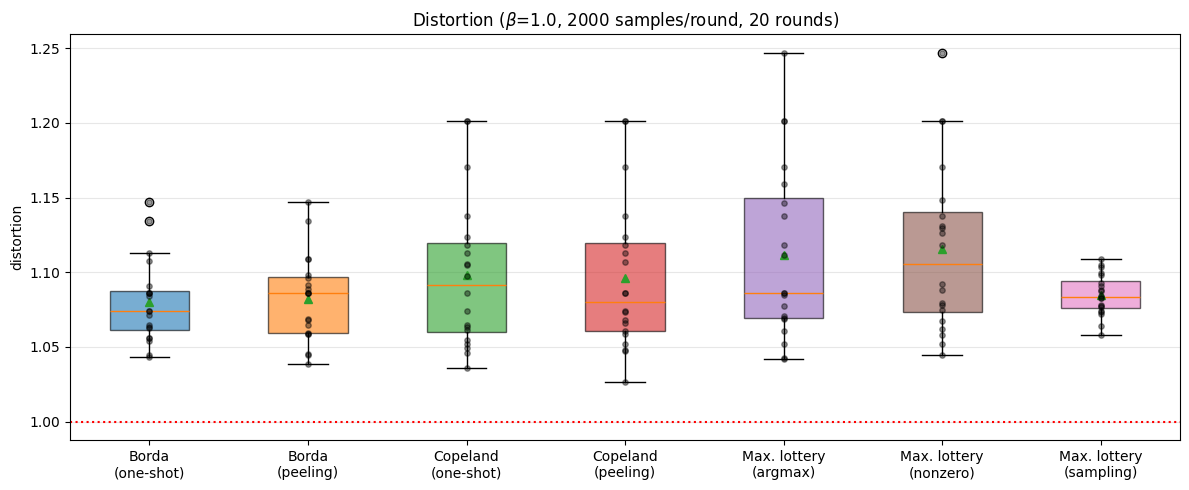

In [ ]:
import matplotlib.pyplot as plt

labels = {
    'borda':            'Borda\n(one-shot)',
    'borda_peeling':    'Borda\n(peeling)',
    'copeland':         'Copeland\n(one-shot)',
    'copeland_peeling': 'Copeland\n(peeling)',
    'ml_argmax':        'Max. lottery\n(argmax)',
    'ml_nonzero':       'Max. lottery\n(nonzero)',
    'ml_sampling':      'Max. lottery\n(sampling)',
}
colors = [f'C{i}' for i in range(len(methods))]

fig, ax = plt.subplots(figsize=(12, 5))
data = [distortions[m] for m in methods]
bp = ax.boxplot(data, tick_labels=[labels[m] for m in methods], patch_artist=True,
                 showmeans=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for xi, m in enumerate(methods, start=1):
    ax.scatter(np.full(num_rounds, xi), distortions[m], color='black', alpha=0.4, zorder=3, s=15)

ax.axhline(1.0, color='red', linestyle=':', linewidth=1.5, zorder=2)

ax.set_ylabel('distortion')
ax.set_title(f'Distortion ($\\beta$={beta}, {num_samples} samples/round, {num_rounds} rounds)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.special import expit
from tqdm import tqdm

from utils_3 import leaderboard_dist
from utils_4 import (
    ij_from_pairwise,
    borda_ranking, borda_peeling_ranking,
    copeland_ranking, copeland_peeling_ranking,
    ml_argmax_ranking, ml_nonzero_ranking,
    expected_leaderboard_distortion,
)
from simulation_35 import sampled_ranking_dist

beta = 1.0
num_samples = 4000
num_rounds = 20
ml_sampling_rounds = 100

true_ranking = np.argsort(-population.avg_utilities)
candidates_idx = np.arange(pw.M)

# uniform distribution over unordered pairs: the leaderboard dataset only
# provides aggregated ratings, not per-pair battle counts to draw from
empirical_pair_distribution = np.ones((pw.M, pw.M))
np.fill_diagonal(empirical_pair_distribution, 0.0)
empirical_pair_distribution /= empirical_pair_distribution.sum()

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling',
           'ml_argmax', 'ml_nonzero', 'ml_sampling']
distortions = {m: [] for m in methods}

for _ in tqdm(range(num_rounds)):
    # sample pairwise comparisons: pairs uniform over candidates,
    # winners from the population utilities (Bradley-Terry with the given beta)
    flattened = empirical_pair_distribution.ravel()
    indices = np.random.choice(len(flattened), size=num_samples, p=flattened)
    coords = np.array(np.unravel_index(indices, empirical_pair_distribution.shape)).T
    model_As = coords[..., 0]
    model_Bs = coords[..., 1]

    u_diff = population.population_utilities[:, model_As] - population.population_utilities[:, model_Bs]
    p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

    for name, fn in [
        ('borda', borda_ranking),
        ('borda_peeling', borda_peeling_ranking),
        ('copeland', copeland_ranking),
        ('copeland_peeling', copeland_peeling_ranking),
        ('ml_argmax', ml_argmax_ranking),
        ('ml_nonzero', ml_nonzero_ranking),
    ]:
        ranking = fn(ij_wins)
        dist, _ = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
        distortions[name].append(dist)

    ranking_dist_sampled = sampled_ranking_dist(candidates_idx, ij_wins, rounds=ml_sampling_rounds)
    dist = expected_leaderboard_distortion(ranking_dist_sampled, true_ranking, population.avg_utilities)
    distortions['ml_sampling'].append(dist)

distortions = {k: np.array(v) for k, v in distortions.items()}
distortions


{'borda': array([1.04947691, 1.045847  , 1.10872281, 1.13093271, 1.04119113,
       1.11853134, 1.05509686, 1.0703833 , 1.10058475, 1.05485031,
       1.0625044 , 1.03370889, 1.07239745, 1.14995674, 1.0475595 ,
       1.11853134, 1.05811462, 1.06080414, 1.06003222, 1.07546471]), 'borda_peeling': array([1.037453  , 1.04723489, 1.09239121, 1.13093271, 1.04522316,
       1.11853134, 1.05717441, 1.05664008, 1.10510428, 1.04616482,
       1.0625044 , 1.03370889, 1.09912892, 1.14995674, 1.0553218 ,
       1.11853134, 1.05185007, 1.0507063 , 1.06003222, 1.07546471]), 'copeland': array([1.05185007, 1.06003222, 1.1003594 , 1.08207987, 1.04210889,
       1.07634538, 1.13779244, 1.08580077, 1.15217315, 1.07583775,
       1.08580077, 1.08580077, 1.09631149, 1.14995674, 1.05020315,
       1.08367066, 1.06349085, 1.04503312, 1.06003222, 1.06022028]), 'copeland_peeling': array([1.05185007, 1.06003222, 1.10786197, 1.08207987, 1.05481426,
       1.0646969 , 1.13779244, 1.08580077, 1.15217315, 1.1009710

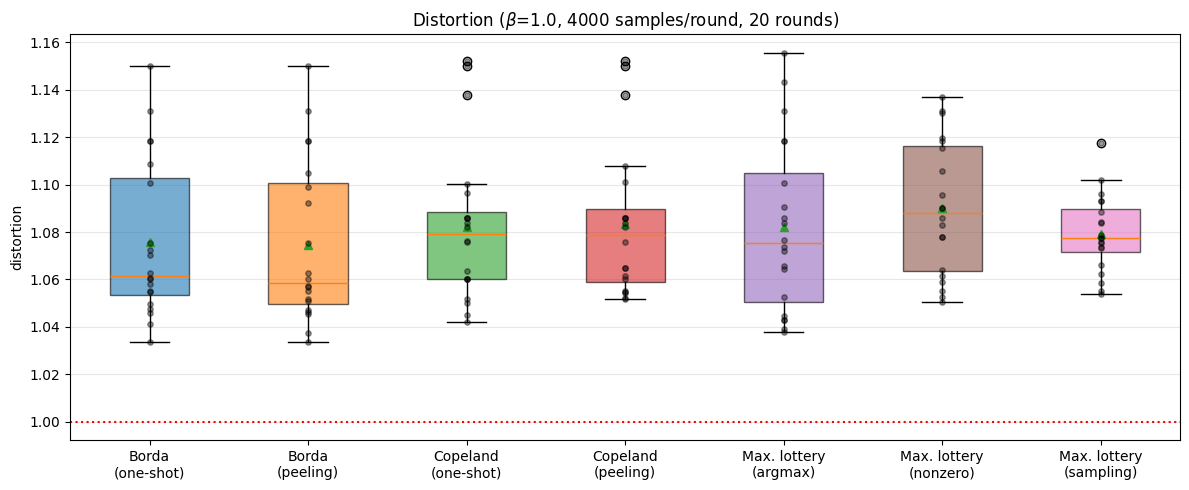

In [ ]:
import matplotlib.pyplot as plt

labels = {
    'borda':            'Borda\n(one-shot)',
    'borda_peeling':    'Borda\n(peeling)',
    'copeland':         'Copeland\n(one-shot)',
    'copeland_peeling': 'Copeland\n(peeling)',
    'ml_argmax':        'Max. lottery\n(argmax)',
    'ml_nonzero':       'Max. lottery\n(nonzero)',
    'ml_sampling':      'Max. lottery\n(sampling)',
}
colors = [f'C{i}' for i in range(len(methods))]

fig, ax = plt.subplots(figsize=(12, 5))
data = [distortions[m] for m in methods]
bp = ax.boxplot(data, tick_labels=[labels[m] for m in methods], patch_artist=True,
                 showmeans=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for xi, m in enumerate(methods, start=1):
    ax.scatter(np.full(num_rounds, xi), distortions[m], color='black', alpha=0.4, zorder=3, s=15)

ax.axhline(1.0, color='red', linestyle=':', linewidth=1.5, zorder=2)

ax.set_ylabel('distortion')
ax.set_title(f'Distortion ($\\beta$={beta}, {num_samples} samples/round, {num_rounds} rounds)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Is the true ranking possible within a confidence interval?

Repeats `simulation_36.ipynb` cells 8-11: bootstrap the one-shot Borda score for each candidate over many resamples of the instance above (`num_samples=4000`), then check whether the true ranking is consistent with the resulting min/max range and 95% CI.

In [ ]:
n_resamples = 1000
ci = 0.95

def sample_ij_wins():
    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    return ij_from_pairwise(w_arr, l_arr, pw.M)

scores = np.array([
    borda_ranking(sample_ij_wins(), with_scores=True)[1]
    for _ in tqdm(range(n_resamples))
])

alpha = 1.0 - ci
ci_lo, ci_hi = np.percentile(scores, [100 * alpha / 2, 100 * (1 - alpha / 2)], axis=0)
score_min, score_max = scores.min(axis=0), scores.max(axis=0)


In [ ]:
def true_ranking_is_possible(true_ranking, lo, hi):
    ceiling = hi[true_ranking[0]]
    for c in true_ranking[1:]:
        if lo[c] >= ceiling:
            return False
        ceiling = min(hi[c], ceiling)
    return True

print('possible with min/max range:', true_ranking_is_possible(true_ranking, score_min, score_max))
print(f'possible with {int(ci*100)}% CI range:', true_ranking_is_possible(true_ranking, ci_lo, ci_hi))


possible with min/max range: True
possible with 95% CI range: True


## Range of one-shot Borda scores per candidate

Repeats `simulation_37.ipynb`: fix a single large instance (`num_samples=100_000`) of sampled pairwise comparisons, bootstrap the one-shot Borda score per candidate over many resamples, and look at how much that range varies across candidates and whether it's still consistent with the true ranking.

In [ ]:
import numpy as np
from scipy.special import expit
from utils_4 import ij_from_pairwise, borda_ranking

beta = 1.0
num_samples = 100_000
n_resamples = 1000
ci = 0.95

# fix a single instance: a sampled set of pairs + their win probabilities
# (uniform over pairs -- no real per-pair battle counts in this dataset)
empirical_pair_distribution = np.ones((pw.M, pw.M))
np.fill_diagonal(empirical_pair_distribution, 0.0)
empirical_pair_distribution /= empirical_pair_distribution.sum()

flattened = empirical_pair_distribution.ravel()
indices = np.random.choice(len(flattened), size=num_samples, p=flattened)
coords = np.array(np.unravel_index(indices, empirical_pair_distribution.shape)).T
model_As = coords[..., 0]
model_Bs = coords[..., 1]

u_diff = (population.population_utilities[:, model_As]
          - population.population_utilities[:, model_Bs])
p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)


In [ ]:
from tqdm.auto import tqdm

def sample_ij_wins():
    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    return ij_from_pairwise(w_arr, l_arr, pw.M)

scores = np.array([
    borda_ranking(sample_ij_wins(), with_scores=True)[1]
    for _ in tqdm(range(n_resamples))
])

alpha = 1.0 - ci
ci_lo, ci_hi = np.percentile(scores, [100 * alpha / 2, 100 * (1 - alpha / 2)], axis=0)

borda_score_range = {
    'mean':  scores.mean(axis=0),
    'std':   scores.std(axis=0),
    'min':   scores.min(axis=0),
    'max':   scores.max(axis=0),
    'ci_lo': ci_lo,
    'ci_hi': ci_hi,
}


In [ ]:
import pandas as pd

df = pd.DataFrame(borda_score_range)
df['candidate'] = np.arange(pw.M)
df['model_name'] = [candidates[i] for i in df['candidate']]
df = df.sort_values('mean', ascending=False).reset_index(drop=True)
df


        mean       std  ...  candidate                               model_name
0   0.523079  0.006067  ...         22                   gemini-3.1-pro-preview
1   0.521099  0.006186  ...         28                 claude-opus-4-5-20251101
2   0.518953  0.006297  ...         20        gemini-3-flash (thinking-minimal)
3   0.518736  0.006161  ...         19               claude-sonnet-4-5-20250929
4   0.518668  0.006089  ...         18  claude-sonnet-4-5-20250929-thinking-32k
5   0.517114  0.006064  ...         24                 claude-opus-4-1-20250805
6   0.515860  0.006335  ...          2                           gemini-2.5-pro
7   0.515124  0.005844  ...         17               chatgpt-4o-latest-20250326
8   0.514059  0.006200  ...         27                                  gpt-5.2
9   0.512078  0.006135  ...         11            qwen3-235b-a22b-instruct-2507
10  0.511318  0.005940  ...          8                claude-haiku-4-5-20251001
11  0.509509  0.006265  ...          3  

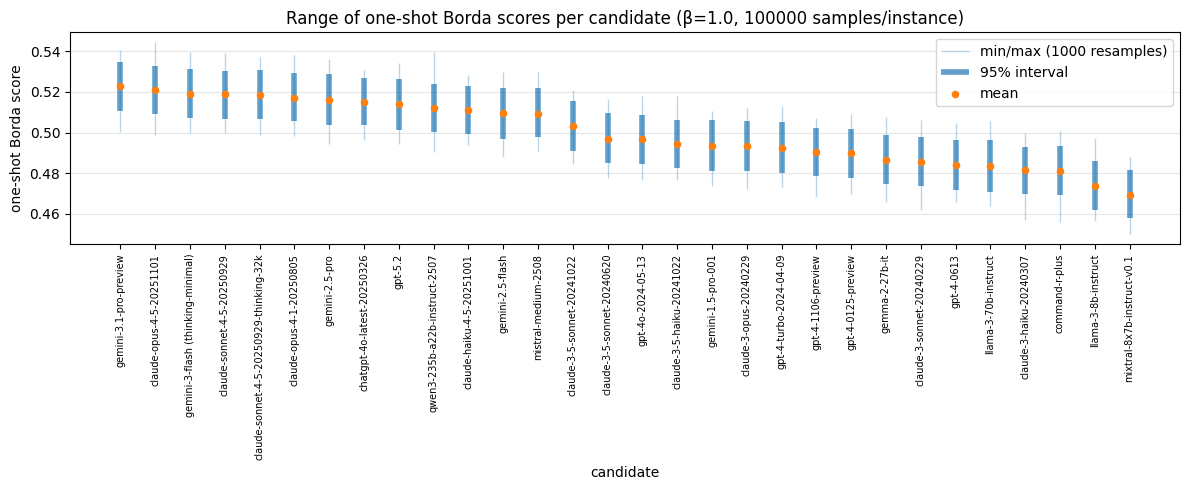

In [ ]:
import matplotlib.pyplot as plt

order = df['candidate'].to_numpy()
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(12, 5))
ax.vlines(x, df['min'], df['max'], color='C0', alpha=0.3, linewidth=1, label=f'min/max ({n_resamples} resamples)')
ax.vlines(x, df['ci_lo'], df['ci_hi'], color='C0', linewidth=4, alpha=0.7, label=f'{int(ci*100)}% interval')
ax.scatter(x, df['mean'], color='C1', zorder=3, s=20, label='mean')

ax.set_xticks(x)
ax.set_xticklabels(df['model_name'], rotation=90, fontsize=7)
ax.set_xlabel('candidate')
ax.set_ylabel('one-shot Borda score')
ax.set_title(f'Range of one-shot Borda scores per candidate (\u03b2={beta}, {num_samples} samples/instance)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
true_ranking = np.argsort(-population.avg_utilities)

def true_ranking_is_possible(true_ranking, lo, hi):
    ceiling = hi[true_ranking[0]]
    for c in true_ranking[1:]:
        if lo[c] >= ceiling:
            return False
        ceiling = min(hi[c], ceiling)
    return True

print('possible with min/max range:', true_ranking_is_possible(
    true_ranking, borda_score_range['min'], borda_score_range['max']))
print(f'possible with {int(ci*100)}% CI range:', true_ranking_is_possible(
    true_ranking, borda_score_range['ci_lo'], borda_score_range['ci_hi']))


possible with min/max range: True
possible with 95% CI range: True
